<a href="https://colab.research.google.com/github/oisincam/quantum_circuits/blob/main/stim_error_propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook creates some tools related to study how errors propagate through a circuit. This can help build intuition for the design of a fault tolerant circuit.

##Imports

In [ ]:
!pip install stim
!pip install cairosvg
import stim
import numpy as np
from IPython.display import SVG, display #for displaying svg with custom colours
import cairosvg # for converting svg to png

##Helper Functions

There are function that help with stabilizer circuits.

In [ ]:
#this function edits the raw svg file to colour in X and Z gates
def ColourErrors(svg_string):
  lines = svg_string.splitlines() #split the svg file into lines
  output_lines = [] # output svg  lines

  for line in lines: # for each line
    if '>Z</text' in line: #if that line is drawing a Z symbol
      output_lines[-1] = output_lines[-1].replace('fill="white"', 'fill="#eb96ad"')#change box from previous line
    if '>X</text' in line: #if that line is drawing a X symbol
      output_lines[-1] = output_lines[-1].replace('fill="white"', 'fill="#F5AC20"')
    if '>Y</text' in line: #if that line is drawing a Y symbol
      output_lines[-1] = output_lines[-1].replace('fill="white"', 'fill="#faf86b"')



    output_lines.append(line)
  return '\n'.join(output_lines)





In [ ]:
# This function allows us to easily view a circuit
def ViewC(circuit, colours = False):
  raw_svg = circuit.diagram('timeline-svg').__str__()
  if colours == True:
    new_svg = ColourErrors(raw_svg)
    return print(display(SVG(new_svg)))
  else:
    return print(display(SVG(raw_svg)))

In [ ]:
#A function that takes in a stim circuit and saves a png of the svg-diagram
def CircuitToPNG(stim_circuit):
  svg_string = stim_circuit.diagram('timeline-svg').__str__()
  path = 'circuit_image.png'
  cairosvg.svg2png(bytestring=ColourErrors(svg_string).encode('utf-8'),write_to=path)

In [ ]:
#turns a pauli stim into a circuit that applies the Pauli stim
def PauliToCircuit(stimPauli,identities = False):
  circuit=stim.Circuit()
  n=len(stimPauli.__str__())
  for i in range(1,n):

    if identities == True: #optional arg to add identity blocks

      if stimPauli.__str__()[i]=='_':
        circuit.append('I', i-1) #i-1 since we skipped the + at start of string
      if stimPauli.__str__()[i]!='_':
        circuit.append(stimPauli.__str__()[i], i-1)
    else:
      if stimPauli.__str__()[i]!='_':
        circuit.append(stimPauli.__str__()[i], i-1)
  return circuit


In [ ]:
TICK = stim.Circuit('TICK')
#padding just for visuals
padding=stim.Circuit()
for i in range(0,5):
  padding.append('I', 0)

#Targeted Error Propogation

In this section, we will look at inserting an error into a circuit, and computing the propagated error.

In [ ]:
#this is a random circuit from another project which we will insert errors to
#important that each gate involves only 1 or 2 qubits, with a TICK after each
flag_measure1=stim.Circuit('''
H 0
TICK
CNOT 0 5
TICK
H 0
TICK
CNOT 6 5
TICK
CNOT 1 5
TICK
CNOT 2 5
TICK
CNOT 6 5
TICK
H 3
TICK
CNOT 3 5
TICK
H 3
TICK
''')

In [ ]:
n = flag_measure1.num_qubits

In [ ]:
(flag_measure1).diagram()

q0: -H-@-H---------------
       |
q1: ---|-----@-----------
       |     |
q2: ---|-----|-@---------
       |     | |
q3: ---|-----|-|---H-@-H-
       |     | |     |
q4: ---|-----|-|-----|---
       |     | |     |
q5: ---X---X-X-X-X---X---
           |     |
q6: -------@-----@-------

In [ ]:
#Creates a list of circuit steps, as circuits
def CircuitToSteps(circuit):
  circuit_steps=[]
  for i  in range(len(circuit.__str__().split('\n')) ):
    circuit_steps.append(stim.Circuit(circuit.__str__().split('\n')[i]))
  return circuit_steps


In [ ]:
#this function returns a list of gate steps which are not TICKS
def Gate_Steps(circuit):
  circuit_steps = CircuitToSteps(circuit)
  gate_steps=[] # a list of steps that are not ticks
  for i in range(0,len(circuit_steps)):
    if circuit_steps[i].__str__() != 'TICK':
      gate_steps.append(i)
  return gate_steps

In [ ]:
#This will insert an error into a circuit, and we can see it propogate
#the step is the gate step, not the circuit step
def ErrorPropCircuit(circuit,erroneous_step,error):

  circuit_steps=CircuitToSteps(circuit)
  gate_steps = Gate_Steps(circuit)

  circuit_left_of_error=stim.Circuit()
  circuit_right_of_error=stim.Circuit()

  for i in range(0,erroneous_step+1):
    circuit_left_of_error += circuit_steps[gate_steps[i]]

  for i in range(erroneous_step+1, len(gate_steps)):
    circuit_right_of_error += circuit_steps[gate_steps[i]]

  error_circuit_before_prop = circuit_left_of_error + TICK + PauliToCircuit(error) + TICK + circuit_right_of_error

  propogated_error=error.after(circuit_right_of_error)

  error_circuit_after_prop = circuit_left_of_error + TICK + circuit_right_of_error + TICK +  PauliToCircuit(propogated_error)
  return (error_circuit_before_prop + TICK + padding + TICK + PauliToCircuit(propogated_error))

In [ ]:
prop_circuit = ErrorPropCircuit(flag_measure1, 4, stim.PauliString('IIIIIZI'))

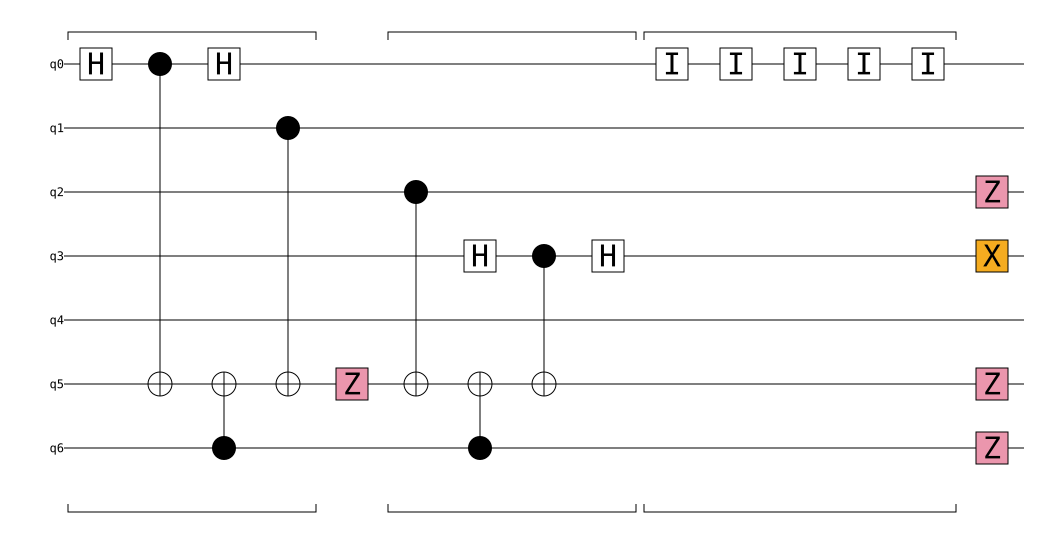

None


In [ ]:
ViewC(prop_circuit,colours = True)

#Enumeration of Propogated Errors

Now we want to take a circuit, compute all possible errors that could occur, and compute all possible error propagations. We want to save them as stimPaulis, and also save all the visualisations as pngs.

##Enumerating all gate errors

In [ ]:
flag_measure1

stim.Circuit('''
    H 0
    TICK
    CX 0 5
    TICK
    H 0
    TICK
    CX 6 5
    TICK
    CX 1 5
    TICK
    CX 2 5
    TICK
    CX 6 5
    TICK
    H 3
    TICK
    CX 3 5
    TICK
    H 3
    TICK
''')

In [ ]:
#Example
Gate_Steps(flag_measure1)
#should all be even if properly structured

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [ ]:
#This function returns two lists, listing the 1 or 2 qubit gate steps respectively
def Gate_Extractor(circuit):
  circuit_steps = CircuitToSteps(circuit)
  gate_steps = Gate_Steps(circuit)
  OneQubit_gate_steps = []
  TwoQubit_gate_steps = []
  for i in gate_steps:
    if len(circuit_steps[i].__str__().split(' ')) == 2: # one space means 1 qubit involved
      OneQubit_gate_steps.append(i)
    elif len(circuit_steps[i].__str__().split(' ')) == 3: # two spaces means 2 qubits involved
      TwoQubit_gate_steps.append(i)
    else:
      raise TypeError('Each TICK can only involve 2 qubits, there must be no leading blanks on each line')
  return OneQubit_gate_steps, TwoQubit_gate_steps

In [ ]:
#Example of gate extraction
circuit_steps = CircuitToSteps(flag_measure1)
ones,twos = Gate_Extractor(flag_measure1)
print('The one qubit gates are:')
for i in ones:
  print(circuit_steps[i].__str__())
print('The two qubit gates are:')
for i in twos:
  print(circuit_steps[i].__str__())

The one qubit gates are:
H 0
H 0
H 3
H 3
The two qubit gates are:
CX 0 5
CX 6 5
CX 1 5
CX 2 5
CX 6 5
CX 3 5


In [ ]:
# This function takes in a stim circuit, and returns a list of possible gate errors
# The circuit must be broken into steps of only 1 and 2 qubit gates (ie no big CNOT lines)
#If multiple CNOTS, use ticks
def Gate_Errors(circuit):
  n = circuit.num_qubits

  circuit_steps = CircuitToSteps(circuit) # break the circuit into steps given by lines.
  gate_steps = Gate_Steps(circuit)


  # We split into 1 and 2 qubit gates

  OneQubit_gate_steps, TwoQubit_gate_steps = Gate_Extractor(circuit)

  #now we create the list of possible errors, along with circuit step
  blank_error = ''
  for i in range(0,n):
    blank_error+= '_'
  Paulis='IXZY'
  gate_errors = []
  for i in OneQubit_gate_steps: # for each single qubit gate
    for pauli in Paulis: #for each single qubit pauli
      qubit = int(circuit_steps[i].__str__().split(' ')[1]) #which qubit is the gate operating on
      error = blank_error[:qubit] + pauli + blank_error[qubit+1:] # create the error string
      gate_errors.append( (int(i/2), error)) # we return the gate step, which is the circuit_step/2

  for i in TwoQubit_gate_steps:
    for pauli_one in Paulis:
      for pauli_two in Paulis: #we pick a pair of pauli operators

        qubit_one = int(circuit_steps[i].__str__().split(' ')[1]) # first qubit in gate
        qubit_two = int(circuit_steps[i].__str__().split(' ')[2]) # second qubit in gate

        if qubit_one < qubit_two:
          error = blank_error[:qubit_one] + pauli_one + blank_error[qubit_one+1:qubit_two] + pauli_two + blank_error[qubit_two+1:]
        elif qubit_two < qubit_one:
          error = blank_error[:qubit_two] + pauli_one + blank_error[qubit_two+1:qubit_one] + pauli_two + blank_error[qubit_one+1:]
        gate_errors.append((int(i/2),error)) # we return the gate step, which is the circuit_step/2

  return gate_errors




In [ ]:
#Example of gate_errors list
Gate_Errors(flag_measure1)

[(0, 'I______'),
 (0, 'X______'),
 (0, 'Z______'),
 (0, 'Y______'),
 (2, 'I______'),
 (2, 'X______'),
 (2, 'Z______'),
 (2, 'Y______'),
 (7, '___I___'),
 (7, '___X___'),
 (7, '___Z___'),
 (7, '___Y___'),
 (9, '___I___'),
 (9, '___X___'),
 (9, '___Z___'),
 (9, '___Y___'),
 (1, 'I____I_'),
 (1, 'I____X_'),
 (1, 'I____Z_'),
 (1, 'I____Y_'),
 (1, 'X____I_'),
 (1, 'X____X_'),
 (1, 'X____Z_'),
 (1, 'X____Y_'),
 (1, 'Z____I_'),
 (1, 'Z____X_'),
 (1, 'Z____Z_'),
 (1, 'Z____Y_'),
 (1, 'Y____I_'),
 (1, 'Y____X_'),
 (1, 'Y____Z_'),
 (1, 'Y____Y_'),
 (3, '_____II'),
 (3, '_____IX'),
 (3, '_____IZ'),
 (3, '_____IY'),
 (3, '_____XI'),
 (3, '_____XX'),
 (3, '_____XZ'),
 (3, '_____XY'),
 (3, '_____ZI'),
 (3, '_____ZX'),
 (3, '_____ZZ'),
 (3, '_____ZY'),
 (3, '_____YI'),
 (3, '_____YX'),
 (3, '_____YZ'),
 (3, '_____YY'),
 (4, '_I___I_'),
 (4, '_I___X_'),
 (4, '_I___Z_'),
 (4, '_I___Y_'),
 (4, '_X___I_'),
 (4, '_X___X_'),
 (4, '_X___Z_'),
 (4, '_X___Y_'),
 (4, '_Z___I_'),
 (4, '_Z___X_'),
 (4, '_Z___Z_'

##Enumerating Propagated Errors

In [ ]:
#This function takes in a stim circuit, and returns a list of triples, (step, gate_error, propagated_error)
def Enumerate_Propogated_Errors(circuit):
  gate_steps = Gate_Steps(circuit)
  circuit_steps = CircuitToSteps(circuit)
  gate_errors = Gate_Errors(circuit)#

  propagated_errors = []

  for pair in gate_errors:
    step, gate_error = pair
    left_of_error = stim.Circuit()
    right_of_error = stim.Circuit()

    for i in range(0,step+1):
      left_of_error += circuit_steps[gate_steps[i]]
    for i in range(step+1,len(gate_steps)):
      right_of_error += circuit_steps[gate_steps[i]]
    propagated_error = stim.PauliString(gate_error).after(right_of_error)

    propagated_errors.append((step,gate_error,propagated_error))

  return propagated_errors

In [ ]:
Gate_Errors(flag_measure1)

[(0, 'I______'),
 (0, 'X______'),
 (0, 'Z______'),
 (0, 'Y______'),
 (2, 'I______'),
 (2, 'X______'),
 (2, 'Z______'),
 (2, 'Y______'),
 (7, '___I___'),
 (7, '___X___'),
 (7, '___Z___'),
 (7, '___Y___'),
 (9, '___I___'),
 (9, '___X___'),
 (9, '___Z___'),
 (9, '___Y___'),
 (1, 'I____I_'),
 (1, 'I____X_'),
 (1, 'I____Z_'),
 (1, 'I____Y_'),
 (1, 'X____I_'),
 (1, 'X____X_'),
 (1, 'X____Z_'),
 (1, 'X____Y_'),
 (1, 'Z____I_'),
 (1, 'Z____X_'),
 (1, 'Z____Z_'),
 (1, 'Z____Y_'),
 (1, 'Y____I_'),
 (1, 'Y____X_'),
 (1, 'Y____Z_'),
 (1, 'Y____Y_'),
 (3, '_____II'),
 (3, '_____IX'),
 (3, '_____IZ'),
 (3, '_____IY'),
 (3, '_____XI'),
 (3, '_____XX'),
 (3, '_____XZ'),
 (3, '_____XY'),
 (3, '_____ZI'),
 (3, '_____ZX'),
 (3, '_____ZZ'),
 (3, '_____ZY'),
 (3, '_____YI'),
 (3, '_____YX'),
 (3, '_____YZ'),
 (3, '_____YY'),
 (4, '_I___I_'),
 (4, '_I___X_'),
 (4, '_I___Z_'),
 (4, '_I___Y_'),
 (4, '_X___I_'),
 (4, '_X___X_'),
 (4, '_X___Z_'),
 (4, '_X___Y_'),
 (4, '_Z___I_'),
 (4, '_Z___X_'),
 (4, '_Z___Z_'

In [ ]:
Enumerate_Propogated_Errors(flag_measure1)

[(0, 'I______', stim.PauliString("+_______")),
 (0, 'X______', stim.PauliString("+Z____X_")),
 (0, 'Z______', stim.PauliString("+X______")),
 (0, 'Y______', stim.PauliString("-Y____X_")),
 (2, 'I______', stim.PauliString("+_______")),
 (2, 'X______', stim.PauliString("+X______")),
 (2, 'Z______', stim.PauliString("+Z______")),
 (2, 'Y______', stim.PauliString("+Y______")),
 (7, '___I___', stim.PauliString("+_______")),
 (7, '___X___', stim.PauliString("+___Z_X_")),
 (7, '___Z___', stim.PauliString("+___X___")),
 (7, '___Y___', stim.PauliString("-___Y_X_")),
 (9, '___I___', stim.PauliString("+_______")),
 (9, '___X___', stim.PauliString("+___X___")),
 (9, '___Z___', stim.PauliString("+___Z___")),
 (9, '___Y___', stim.PauliString("+___Y___")),
 (1, 'I____I_', stim.PauliString("+_______")),
 (1, 'I____X_', stim.PauliString("+_____X_")),
 (1, 'I____Z_', stim.PauliString("+_ZZX_Z_")),
 (1, 'I____Y_', stim.PauliString("+_ZZX_Y_")),
 (1, 'X____I_', stim.PauliString("+Z______")),
 (1, 'X____X_

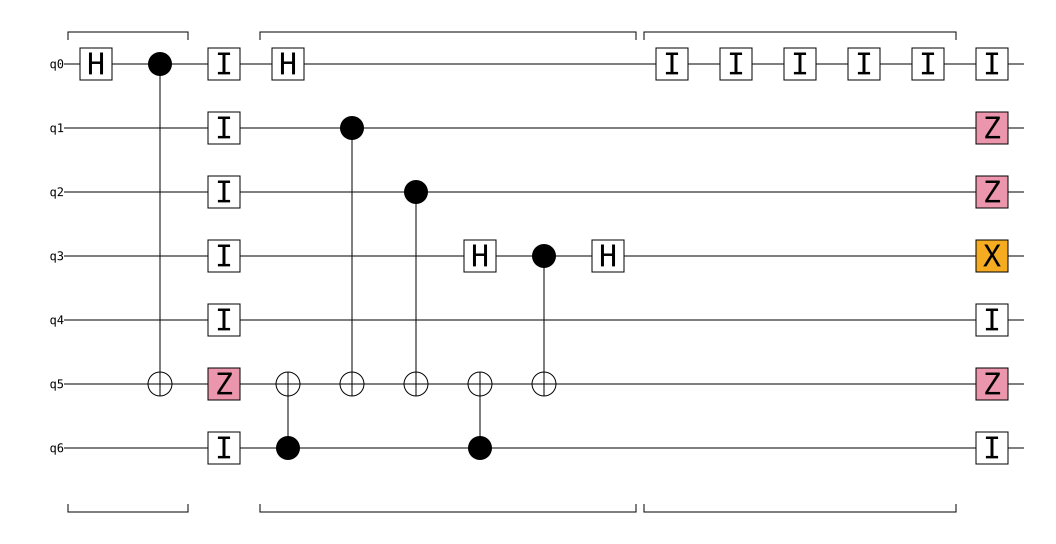

None


In [ ]:
e_step, g_error, p_error= Enumerate_Propogated_Errors(flag_measure1)[18]
prop_circuit = ErrorPropCircuit(flag_measure1, e_step, stim.PauliString(g_error))

ViewC(prop_circuit, colours = True)

##Printing Pictures

In [ ]:
# I robbed this from stack exchange, to combine images. I changed it a bit to look better for our circuits.
from PIL import Image


def combine_images(rows, space, images, file_name):
    columns = len(images) // rows
    if len(images) % rows:
        columns += 1
    width_max = max([Image.open(image).width for image in images])
    height_max = max([Image.open(image).height for image in images])
    background_width = width_max*columns + (space*columns)-space
    background_height = height_max*rows + (space*rows)-space
    background = Image.new('RGBA', (background_width, background_height), (255, 255, 255, 255))
    x = 0
    y = 0
    for i, image in enumerate(images):
        img = Image.open(image)
        x_offset = int((width_max-img.width)/2)
        y_offset = int((height_max-img.height)/2)
        background.paste(img, (y+y_offset, x+x_offset ))
        x += height_max + space
        if (i+1) % rows == 0:
            y += width_max + space
            x = 0
    background.save(file_name)




In [ ]:
#Create an image visualising all 16 single qubit error
paths1 = []
for i in range(0,16):
  e_step, g_error, p_error= Enumerate_Propogated_Errors(flag_measure1)[i]
  prop_circuit = ErrorPropCircuit(flag_measure1, e_step, stim.PauliString(g_error))
  diagram_string = ColourErrors(prop_circuit.diagram('timeline-svg').__str__())
  path = 'circuit'+ str(i) + '.png'
  paths1.append(path)
  #cairosvg.svg2png(bytestring=diagram_string.encode('utf-8'),write_to=path)

# combine_images(rows=4, space=20, images=paths1) # each row is all possible errors after a gate

In [ ]:
paths2 = []
for i in range(16,112):
  e_step, g_error, p_error= Enumerate_Propogated_Errors(flag_measure1)[i]
  prop_circuit = ErrorPropCircuit(flag_measure1, e_step, stim.PauliString(g_error))
  diagram_string = ColourErrors(prop_circuit.diagram('timeline-svg').__str__())
  path = 'circuit'+ str(i) + '.png'
  paths2.append(path)
  #cairosvg.svg2png(bytestring=diagram_string.encode('utf-8'),write_to=path)
#combine_images(rows=16, space=20, images=paths2) # each row is all possible errors after a gate

In [ ]:
# combine_images(rows=16, space=20, images=paths2) # each row is all possible errors after a gate

#Error Timeline

I want a separate circuit which just gives a timeline of the errors at each time step. We can print it above the real circuit and watch the errors propgate in real time.

In [ ]:
def ErrorPropTimeline(circuit,erroneous_gate_step,error, png = False):
  #call the helper functions
  circuit_steps=CircuitToSteps(circuit) # list of all circuit steps including ticks
  gate_steps = Gate_Steps(circuit) # list of indexes of non-tick gates
  n=circuit.num_qubits


  #First we insert the error into the actual circuit for visual purposes
  circuit_left_of_error = stim.Circuit()
  circuit_right_of_error = stim.Circuit()
  for i in range(0, erroneous_gate_step+1):
    circuit_left_of_error += circuit_steps[gate_steps[i]]
    circuit_left_of_error += TICK

  for i in range(erroneous_gate_step+1,len(gate_steps)):
    circuit_right_of_error += circuit_steps[gate_steps[i]]
    circuit_right_of_error += TICK
  circuit_with_error = circuit_left_of_error + PauliToCircuit(error,identities=True) + TICK + circuit_right_of_error


   #create the error timeline
  error_timeline = stim.Circuit()
  for i in range(0,erroneous_gate_step+1): #We add identities up until the error
    error_timeline.append('I',[i for i in range(0,n)])
  error_timeline += PauliToCircuit(error, identities=True) #add the new error into the timeline
  error_timeline += PauliToCircuit(error, identities=True) #add it again to offset the timelines by 1

  for gate in gate_steps[erroneous_gate_step+1:]:
    error = error.after(circuit_steps[gate])#propagate the error by one gate
    error_timeline += PauliToCircuit(error,identities=True) #Add the propagated error to the timeline

  #the ith tick of the error timeline shows the error after gate i-1
  if png == True: #optional arg to make a picture of the timeline
    cairosvg.svg2png(bytestring=ColourErrors(error_timeline.diagram('timeline-svg').__str__()).encode('utf-8'),write_to='error_timeline.png')
    cairosvg.svg2png(bytestring=ColourErrors(circuit_with_error.diagram('timeline-svg').__str__()).encode('utf-8'),write_to='circuit_timeline.png')
    combine_images(rows = 2, space = 20, images = ['error_timeline.png', 'circuit_timeline.png'], file_name = 'circuit_with_error_timeline.png')
    print(error_timeline.diagram())
    print(circuit_with_error.diagram())
  return error_timeline.diagram()

We can combine this with our enumerator to get timelines for all propagated errors.

In [ ]:
circuit = flag_measure1
step, error_string = Gate_Errors(circuit)[54]
ErrorPropTimeline(circuit,step,stim.PauliString(error_string),png =True)

q0: -I-I-I-I-I-I-I-I-I-I-I-I-

q1: -I-I-I-I-I-X-X-X-X-X-X-X-

q2: -I-I-I-I-I-I-I-Z-Z-Z-Z-Z-

q3: -I-I-I-I-I-I-I-I-I-I-Z-X-

q4: -I-I-I-I-I-I-I-I-I-I-I-I-

q5: -I-I-I-I-I-Z-Z-Z-Z-Z-Z-Z-

q6: -I-I-I-I-I-I-I-I-Z-Z-Z-Z-
q0: -H-@-H-----I-----------
       |
q1: ---|-----@-X-----------
       |     |
q2: ---|-----|-I-@---------
       |     |   |
q3: ---|-----|-I-|---H-@-H-
       |     |   |     |
q4: ---|-----|-I-|-----|---
       |     |   |     |
q5: ---X---X-X-Z-X-X---X---
           |       |
q6: -------@---I---@-------


q0: -I-I-I-I-I-I-I-I-I-I-I-I-

q1: -I-I-I-I-I-X-X-X-X-X-X-X-

q2: -I-I-I-I-I-I-I-Z-Z-Z-Z-Z-

q3: -I-I-I-I-I-I-I-I-I-I-Z-X-

q4: -I-I-I-I-I-I-I-I-I-I-I-I-

q5: -I-I-I-I-I-Z-Z-Z-Z-Z-Z-Z-

q6: -I-I-I-I-I-I-I-I-Z-Z-Z-Z-